# Topics Covered
- [1. ReAct Agent Architecture](#1-react-agent-architecture)
- [2. REACT Agent Architecture with Memory Saver](#2-react-agent-architecture-with-memory-saver)
- [3. Different Streaming Techniques](#3-different-streaming-techniques)
    - [3.1. stream() method](#31-stream-method)
    - [3.2. astream() method](#32-astream-method)

### 1. ReAct Agent Architecture
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)![alt text](REACT_architecture.png)

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from pprint import pprint
### Tavily Search Tool
from langchain_tavily import TavilySearch
from langchain_core.messages import AIMessage, HumanMessage
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [ ]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")
langchain_key = os.getenv("LANGCHAIN_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else:
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

if langchain_key is not None:
    os.environ["LANGCHAIN_API_KEY"] = langchain_key
else:
    raise ValueError("LANGCHAIN_API_KEY environment variable is not set.")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-agent"

In [6]:
# seeting up the external tools for LLM to use
#==============================================
# 1. arxiv tool
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500) # type: ignore
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

# 2. wikipedia tool
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500) # type: ignore
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

# 3. tavily search tool
tavily = TavilySearch()

# 4. Custom Functions for math calculations
# add function
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

# multiply function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# divide function
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [7]:
# all tools together
tools=[arxiv,wiki,tavily,add,divide,multiply]

In [8]:
## Initialize my LLM model
llm_openai=ChatOpenAI(model="gpt-4o")

In [9]:
# bind llm with tools
llm_with_tools=llm_openai.bind_tools(tools)

In [10]:
# state schema
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [11]:
### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

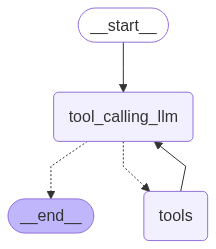

In [12]:
# Build graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
messages=graph.invoke({"messages":[HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")]})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_LODQzPEo5GbHi0OVvehYWkNj)
 Call ID: call_LODQzPEo5GbHi0OVvehYWkNj
  Args:
    query: AI news
    time_range: day
    topic: news
  add (call_3Jg4B4eixU1IoMQNGtOMOJci)
 Call ID: call_3Jg4B4eixU1IoMQNGtOMOJci
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mobihealthnews.com/news/asia/indian-ai-startup-nets-7m-us-expansion-and-more-ai-briefs", "title": "Indian AI startup nets $7M for US expansion and more AI briefs - Mobi Health News", "score": 0.6651719, "published_date": "Mon, 08 Sep 2025 00:29:40 GMT", "content

### 2. REACT Agent Architecture with Memory Saver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

![alt text](memory_saver.png)



In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [22]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from pprint import pprint
### Tavily Search Tool
from langchain_tavily import TavilySearch
from langchain_core.messages import AIMessage, HumanMessage
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


In [17]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")
langchain_key = os.getenv("LANGCHAIN_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else:
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

if langchain_key is not None:
    os.environ["LANGCHAIN_API_KEY"] = langchain_key
else:
    raise ValueError("LANGCHAIN_API_KEY environment variable is not set.")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-agent"

In [18]:
# seeting up the external tools for LLM to use
#==============================================
# 1. arxiv tool
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500) # type: ignore
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

# 2. wikipedia tool
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500) # type: ignore
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

# 3. tavily search tool
tavily = TavilySearch()

# 4. Custom Functions for math calculations
# add function
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

# multiply function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# divide function
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [19]:
# all tools together
tools=[arxiv,wiki,tavily,add,divide,multiply]

In [20]:
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

In [33]:
# state schema
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [21]:
### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")

In [23]:
memory=MemorySaver() 
graph_memory = builder.compile(checkpointer=memory)

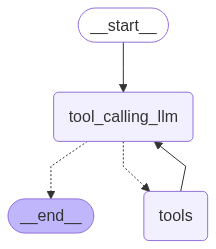

In [24]:
# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [ ]:
## Specify the thread
config = {"configurable": {"thread_id": "1"}}
# Specify an input
messages = HumanMessage(content="Add 12 and 13.")
messages = graph_memory.invoke({"messages": [messages]}, config=config) # type: ignore
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_Y0K5Qag693iSGGvyy9aWFjKP)
 Call ID: call_Y0K5Qag693iSGGvyy9aWFjKP
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

12 plus 13 equals 25.


In [26]:
messages = HumanMessage(content="add that number to 25")
messages=graph_memory.invoke({"messages": [messages]},config=config) # type: ignore
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_Y0K5Qag693iSGGvyy9aWFjKP)
 Call ID: call_Y0K5Qag693iSGGvyy9aWFjKP
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

12 plus 13 equals 25.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_Y4CnXZaftufVqvlYKjJ3PZA1)
 Call ID: call_Y4CnXZaftufVqvlYKjJ3PZA1
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

Adding 25 to 25 gives you

In [27]:
messages = HumanMessage(content="then multiplty that number by 2")
messages=graph_memory.invoke({"messages":[messages]},config=config) # type: ignore
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_Y0K5Qag693iSGGvyy9aWFjKP)
 Call ID: call_Y0K5Qag693iSGGvyy9aWFjKP
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

12 plus 13 equals 25.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_Y4CnXZaftufVqvlYKjJ3PZA1)
 Call ID: call_Y4CnXZaftufVqvlYKjJ3PZA1
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

Adding 25 to 25 gives you

### 3. Different Streaming Techniques
Methods: .stream() and .astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.
![alt text](Streaming.png)

#### 3.1. stream() method

In [28]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

In [30]:
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

In [35]:
llm=ChatOpenAI(model="gpt-4o")

In [34]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

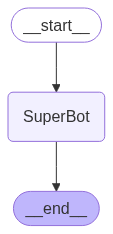

In [37]:
memory=MemorySaver()

def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#### invoke vs stream

In [42]:
## Invocation
config = {"configurable": {"thread_id": "1"}}
results = graph_builder.invoke({'messages':[HumanMessage(content = "Hi,My name is Krish And I like cricket")]},config) # type: ignore

In [43]:
for msg in results['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi,My name is Krish And I like cricket
================================== Ai Message ==================================

Hi Krish! It's great to meet you. Cricket is an exciting sport with a lot of strategy and action. Do you have a favorite team or player?
================================ Human Message =================================

Hi,My name is Krish And I like cricket
================================== Ai Message ==================================

Hi Krish! It's nice to meet you. Cricket is a fantastic sport with a rich history and lots of thrilling moments. Who's your favorite team or player?
================================ Human Message =================================

Hi,My name is Krish And I like cricket
================================== Ai Message ==================================

Hi Krish! It's great to hear that you enjoy cricket. It's such an exciting game with many passionate fans

In [46]:
# stream
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':[HumanMessage(content = "Hi,My name is Krish And I like cricket")]},
                                  config, stream_mode="updates"): # type: ignore
    print(chunk)


{'SuperBot': {'messages': [AIMessage(content="Hi Krish! It's great to meet you. Cricket is a fantastic sport with a rich history and lots of excitement. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 18, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CDLsxjUJmPBZSNht6dpuizOdndJTw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--ef03edd2-933a-4189-a35a-60b8225846a3-0', usage_metadata={'input_tokens': 18, 'output_tokens': 33, 'total_tokens': 51, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [47]:
for chunk in graph_builder.stream({'messages':[HumanMessage(content = "I also like football")]},
                                  config, stream_mode="values"): # type: ignore
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='313cc982-3fb2-4537-a45a-3511d3cee810'), AIMessage(content="Hi Krish! It's great to meet you. Cricket is a fantastic sport with a rich history and lots of excitement. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 18, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CDLsxjUJmPBZSNht6dpuizOdndJTw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--ef03edd2-933a-4189-a35a-60b8225846a3-0', usage_metadata={'input_tokens': 18, 'output_tokens': 33, 'total_tokens': 51, 'inp

#### 3.2. astream method
**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [48]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":[HumanMessage(content = "Hi My name is Krish and I like to play cricket")]},
                                                config, version="v2"): # type: ignore
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': 'd64ff02c-b283-4e72-ba29-e85884f1ca47', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='313cc982-3fb2-4537-a45a-3511d3cee810'), AIMessage(content="Hi Krish! It's great to meet you. Cricket is a fantastic sport with a rich history and lots of excitement. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 18, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_